In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
%pwd

'd:\\ML PROJECTS\\AI-Based-Resume-analyser\\notebook'

In [3]:
os.chdir('../')
%pwd

'd:\\ML PROJECTS\\AI-Based-Resume-analyser'

In [11]:
path = "data/ResumeDataSet.csv"
df = pd.read_csv(path)

In [12]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [6]:
df.shape

(962, 2)

## Exploring Categories

In [13]:
df["Category"].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

In [7]:
df["Category"].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

In [8]:
len(df["Category"].unique())

25

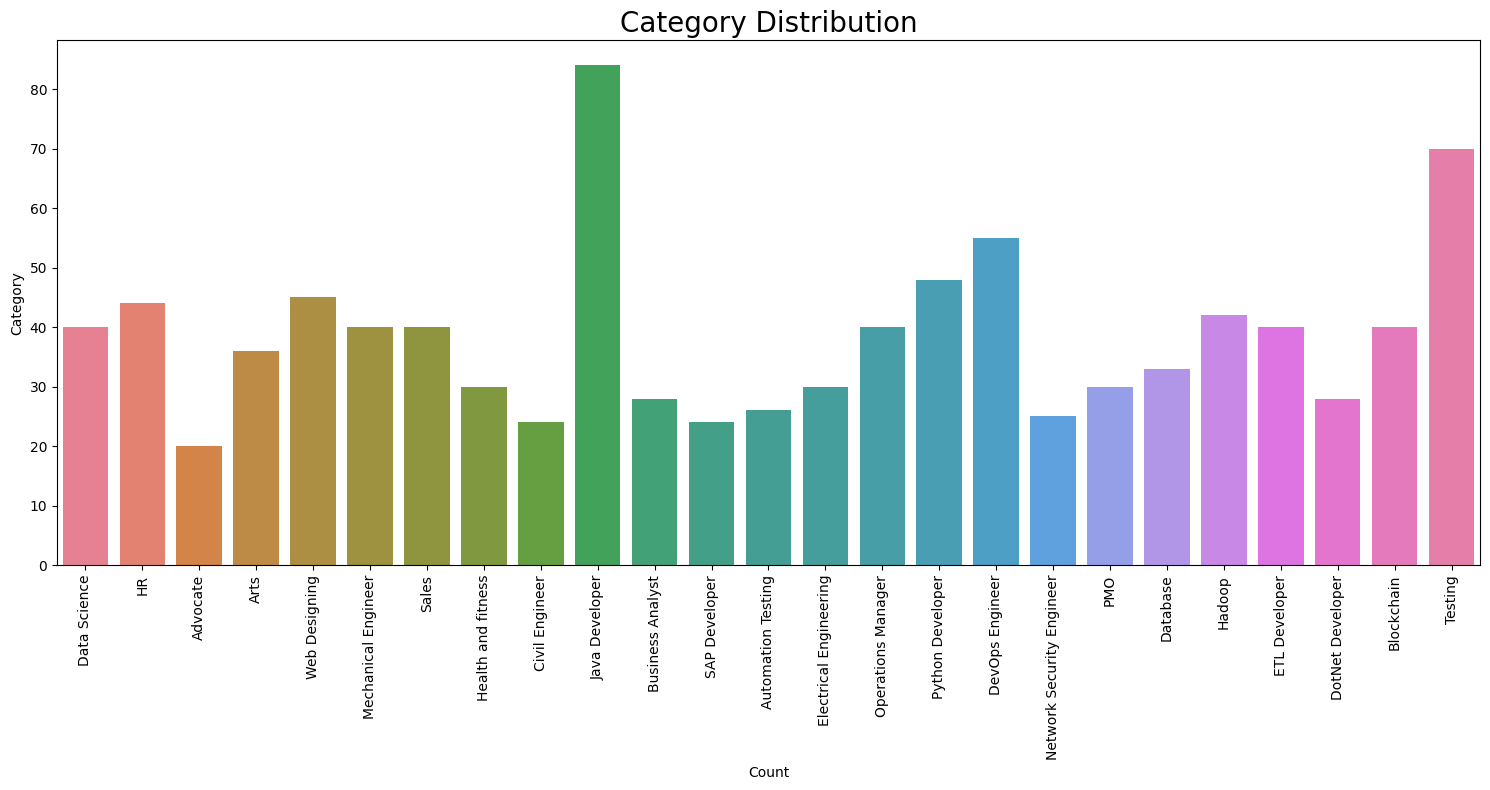

In [9]:
plt.figure(figsize=(15, 8)) 

sns.countplot(x=df["Category"], hue=df["Category"])

plt.title("Category Distribution", fontsize=20)
plt.xticks(rotation=90)
plt.xlabel("Count")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

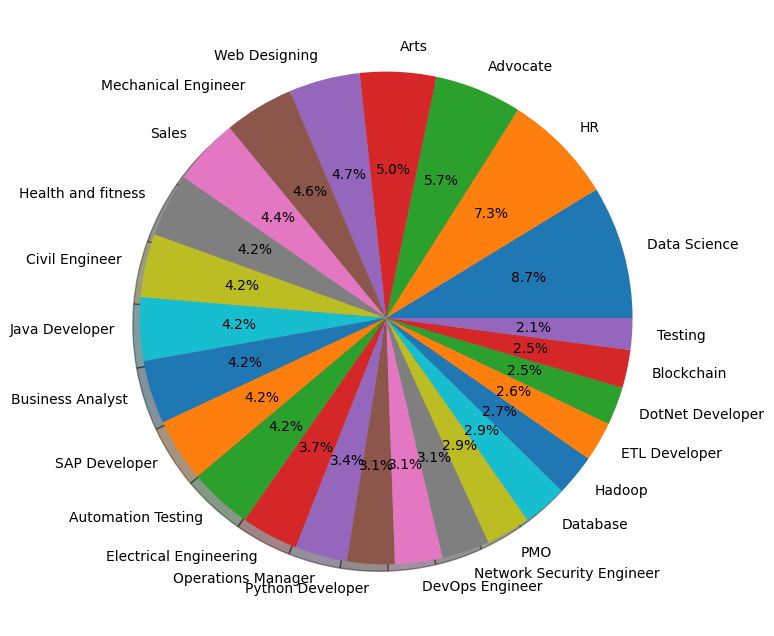

In [10]:
counts = df["Category"].value_counts()
labels = df["Category"].unique()

plt.figure(figsize=(10, 8))
plt.pie(counts, labels=labels, autopct='%1.1f%%', shadow=True)
plt.show()

## Exploring Resume

In [9]:
df["Category"][0]

'Data Science'

In [10]:
df["Resume"][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

## Cleaning Data
1. URLs
2. hashtags
3. mentions
4. special letters
5. punctuations.

In [6]:
import re
import unicodedata

def cleanResume(txt):
    # 1. Remove URLs and emails
    txt = re.sub(r'http\S+|www\S+', '', txt)
    txt = re.sub(r'\S+@\S+', '', txt)

    # 2. Remove social media noise
    #    Original bug: 'cc+' matched "cc", "ccc"... not the intended pattern
    #    Correct: remove 'RT' as a whole word only
    txt = re.sub(r'\bRT\b', '', txt)
    txt = re.sub(r'#\S+', '', txt)
    txt = re.sub(r'@\S+', '', txt)

    # 3. Normalize unicode — convert accented chars to ASCII equivalents
    #    (e.g. 'é' → 'e', 'ü' → 'u') instead of just stripping them
    txt = unicodedata.normalize('NFKD', txt)
    txt = txt.encode('ascii', 'ignore').decode('ascii')

    # 4. Replace unicode punctuation (smart quotes, em-dash, ellipsis, etc.)
    txt = re.sub(r'[\u2018\u2019\u201c\u201d]', '', txt)  # smart quotes
    txt = re.sub(r'[\u2013\u2014]', ' ', txt)              # en/em dash → space
    txt = re.sub(r'\u2026', ' ', txt)                       # ellipsis → space

    # 5. Remove all punctuation and digits (keep only letters and spaces)
    txt = re.sub(r'[^a-zA-Z\s]', '', txt)

    # 6. Lowercase (critical for NLP — 'Python' and 'python' must match)
    txt = txt.lower()

    # 7. Collapse multiple spaces
    txt = re.sub(r'\s+', ' ', txt).strip()

    return txt

In [12]:
text = "Check my profil676e https://example.com and www.test  com2 now! from #com"
cleanResume(text)

'check my profile and com now from'

In [13]:
df["Resume"] = df['Resume'].apply(lambda row: cleanResume(row))

In [14]:
df

,Category,Resume
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may to may be uitrgpv data s...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills a r a python a sap hana a tableau a sap...
4,Data Science,education details mca ymcaust faridabad haryan...
...,...,...
957,Testing,computer skills a proficient in ms office word...
958,Testing,a willingness to accept the challenges a posit...
959,Testing,personal skills a quick learner a eagerness to...
960,Testing,computer skills software knowledge mspower poi...


## Words into categorical values

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Category"] = label_encoder.fit_transform(df["Category"])

In [16]:
df.head()

,Category,Resume
0,6,skills programming languages python pandas num...
1,6,education details may to may be uitrgpv data s...
2,6,areas of interest deep learning control system...
3,6,skills a r a python a sap hana a tableau a sap...
4,6,education details mca ymcaust faridabad haryan...


## Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

resume_vectors = tfidf.fit_transform(df["Resume"])

In [18]:
resume_vectors.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(962, 7502))

## Spliting

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(resume_vectors, df["Category"],
                                                    test_size=0.2, random_state=42)

In [20]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (769, 7502)
Shape of X_test: (193, 7502)


## Model Training

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf_knn = KNeighborsClassifier()
clf_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
clf_logistics = LogisticRegression()
clf_logistics.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred1 = clf_knn.predict(X_test)
y_pred2 = clf_logistics.predict(X_test)

print("Accuracy of KNN model: ", accuracy_score(y_test, y_pred1))
print("Accuracy of Logistics model: ", accuracy_score(y_test, y_pred2))

Accuracy of KNN model:  0.9844559585492227
Accuracy of Logistics model:  0.9948186528497409


## Predicted System

In [24]:
my_resume = """
 
 
 
 
SUMMARY 
  
EDUCATION 
 
Teerthanker Mahaveer University 
B.Tech CSE with specialization in AI, ML and DL 
 
 
   TECHNICAL SKILLS
                   
Languages:  Python, SQL 
MLOps & Tools: DVC, MLflow, Dagshub, Docker, Git/ GitHub 
Libraries and Frameworks:  NumPy, Pandas, matplotlib, Scikit-Learn, tensorflow/keras, PyTorch 
Data Science Fundamentals:  EDA, Machine Learning, Deep Learning, Problem Solving 
Databases:  PostgreSQL 
 
PROJECTS 
 
AI-Powered Resume Analyzer                                                                                                                        GitHub 
 Developed an AI-powered resume analyzer that matches resumes with job descriptions to generate 
ATS compatibility scores, highlighting matched and missing skills. 
 Implemented a career recommendation system that analyzes uploaded resumes and suggests 
suitable job roles. 
       Technologies Used: Python, Flask, PostgreSQL, NLP, Scikit-learn, spaCy, PyMuPDF, Bcrypt 
Chest Cancer Classification – End-to-End DL Application                                                                          GitHub 
 Developed a CNN-based chest cancer classification system to identify Adenocarcinoma vs Normal 
medical images. with a fully automated ML pipeline for data ingestion, preprocessing, training, 
evaluation, and deployment. 
 Integrated MLflow with Dagshub for experiment tracking, model versioning, and performance 
comparison. 
      Technologies: Python, TensorFlow/Keras, CNN, DVC, MLflow, Dagshub, Docker, Flask, Git 
 
CERTIFICATIONS & COURSES 
 
 Introduction to Machine Learning – NPTEL, 
 Machine Learning – CampusX , 
 Deep Learning – CampusX,  
July 2025  –  August 2025 
January 2025 – August 2025 
September 2025 – December 2025 
 
ACHIEVEMENTS 
 
 Winner of coding contest organizing on nation technology day      LINK 
1600+ rating on Leetcode            LINK 
Yashveer Saini 
(+91) 6397719140  yashveersaini1110@gmail.com LinkedIn Leetcode GitHub
Aspiring Data Scientist with strong foundations in Machine Learning and Deep Learning (tensorflow/Keras). 
Experienced in building end-to-end models, applying transfer learning, and performing data preprocessing 
and analysis using Python and SQL. Skilled in developing and evaluating ML/DL models to deliver actionable 
insights.  
"""

In [25]:
my_resume

'\n\n\n\n\nSUMMARY \n\nEDUCATION \n\nTeerthanker Mahaveer University \nB.Tech CSE with specialization in AI, ML and DL \n\n\n   TECHNICAL SKILLS\n\nLanguages:  Python, SQL \nMLOps & Tools: DVC, MLflow, Dagshub, Docker, Git/ GitHub \nLibraries and Frameworks:  NumPy, Pandas, matplotlib, Scikit-Learn, tensorflow/keras, PyTorch \nData Science Fundamentals:  EDA, Machine Learning, Deep Learning, Problem Solving \nDatabases:  PostgreSQL \n\nPROJECTS \n\nAI-Powered Resume Analyzer                                                                                                                        GitHub \n\uf0b7 Developed an AI-powered resume analyzer that matches resumes with job descriptions to generate \nATS compatibility scores, highlighting matched and missing skills. \n\uf0b7 Implemented a career recommendation system that analyzes uploaded resumes and suggests \nsuitable job roles. \n       Technologies Used: Python, Flask, PostgreSQL, NLP, Scikit-learn, spaCy, PyMuPDF, Bcrypt \nChes

In [26]:
import pickle

pickle.dump(tfidf, open('models/tfidf.pkl', 'wb'))
pickle.dump(clf_knn, open('models/clf_knn.pkl', 'wb'))
pickle.dump(clf_logistics, open('models/clf_logistics.pkl', 'wb'))
pickle.dump(label_encoder, open('models/label_encoder.pkl', 'wb'))

In [7]:
import pickle 


tfidf = pickle.load(open('models/tfidf.pkl', 'rb'))
clf = pickle.load(open('models/clf_logistics.pkl', 'rb'))
label_encoder = pickle.load(open('models/label_encoder.pkl', 'rb'))


def predict_job_role(txt, k):

    my_resume = cleanResume(txt)
    input_features = tfidf.transform([my_resume])

    prediction_prob = clf.predict_proba(input_features)
    top_k_idx = prediction_prob.argsort()[:, -k:][:, ::-1]

    top_k_labels = [label_encoder.inverse_transform(row) for row in top_k_idx]
    top_k_probs = np.take_along_axis(prediction_prob, top_k_idx, axis=1)


    # return label_encoder.inverse_transform(prediction_id)
    return top_k_labels, top_k_probs

In [10]:
my_resume = "LLM, RAG, fine-tuning, openAI, gemini"
predict_job_role(my_resume, 3)

([array(['HR', 'Testing', 'Java Developer'], dtype=object)],
 array([[0.06331175, 0.0595471 , 0.05846033]]))

In [15]:
import re
import unicodedata
import pickle
import numpy as np
import json

# ──────────────────────────────────────────────────────────────
# 1.  CLEANING  (your original function — unchanged)
# ──────────────────────────────────────────────────────────────

def cleanResume(txt):
    txt = re.sub(r'http\S+|www\S+', '', txt)
    txt = re.sub(r'\S+@\S+', '', txt)
    txt = re.sub(r'\bRT\b', '', txt)
    txt = re.sub(r'#\S+', '', txt)
    txt = re.sub(r'@\S+', '', txt)
    txt = unicodedata.normalize('NFKD', txt)
    txt = txt.encode('ascii', 'ignore').decode('ascii')
    txt = re.sub(r'[\u2018\u2019\u201c\u201d]', '', txt)
    txt = re.sub(r'[\u2013\u2014]', ' ', txt)
    txt = re.sub(r'\u2026', ' ', txt)
    txt = re.sub(r'[^a-zA-Z\s]', '', txt)
    txt = txt.lower()
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt


# ──────────────────────────────────────────────────────────────
# 2.  MODEL LOADING  (your original code — unchanged)
# ──────────────────────────────────────────────────────────────

tfidf          = pickle.load(open('models/tfidf.pkl', 'rb'))
clf            = pickle.load(open('models/clf_logistics.pkl', 'rb'))
label_encoder  = pickle.load(open('models/label_encoder.pkl', 'rb'))


# ──────────────────────────────────────────────────────────────
# 3.  YOUR ORIGINAL predict_job_role  (unchanged)
# ──────────────────────────────────────────────────────────────

def predict_job_role(txt, k):
    my_resume       = cleanResume(txt)
    input_features  = tfidf.transform([my_resume])
    prediction_prob = clf.predict_proba(input_features)
    top_k_idx       = prediction_prob.argsort()[:, -k:][:, ::-1]
    top_k_labels    = [label_encoder.inverse_transform(row) for row in top_k_idx]
    top_k_probs     = np.take_along_axis(prediction_prob, top_k_idx, axis=1)
    return top_k_labels, top_k_probs


# ──────────────────────────────────────────────────────────────
# 4.  TRENDING ROLE MAP  (load from your JSON file)
# ──────────────────────────────────────────────────────────────

with open('data/trending_role_map.json', 'r') as f:
    TRENDING_ROLE_MAP = json.load(f)


def _confidence_label(score: float) -> str:
    """Converts a numeric score to a human-readable confidence label."""
    if score >= 0.60:
        return "High"
    elif score >= 0.30:
        return "Medium"
    else:
        return "Low"


# ──────────────────────────────────────────────────────────────
# 5.  TRENDING MAP SCORER
#     Returns matched trending roles sorted by match strength.
# ──────────────────────────────────────────────────────────────

def _score_trending(cleaned_text: str) -> list[dict]:
    """
    Scans cleaned resume text against TRENDING_ROLE_MAP.
    Returns all roles that meet min_matches, sorted by score desc.
    Score = (matched_keywords / total_keywords) + trending_score_boost
    """
    results = []

    for role, config in TRENDING_ROLE_MAP.items():
        keywords      = config["keywords"]
        min_matches   = config["min_matches"]
        boost         = config.get("trending_score_boost", 0.0)
        parent        = config.get("parent_category", "")

        matched = [kw for kw in keywords if kw in cleaned_text]

        if len(matched) >= min_matches:
            base_score = len(matched) / len(keywords)
            final_score = round(base_score + boost, 4)

            results.append({
                "role":           role,
                "score":          final_score,
                "source":         "Trending map",
                "parent_category": parent,
                "matched_skills": matched[:5],          # show top 5 evidence skills
                "confidence":     _confidence_label(final_score),
            })

    return sorted(results, key=lambda x: x["score"], reverse=True)


# ──────────────────────────────────────────────────────────────
# 6.  ML MODEL RESULTS → STRUCTURED FORMAT
#     Wraps your existing predict_job_role into the same dict
#     shape as trending results so the merger works cleanly.
# ──────────────────────────────────────────────────────────────

def _get_ml_predictions(cleaned_text: str, top_n: int = 5) -> list[dict]:
    """
    Calls your LR model and returns results in the same
    dict shape as _score_trending() for easy merging.
    NOTE: cleaned_text is passed directly (already cleaned).
    """
    input_features  = tfidf.transform([cleaned_text])
    prediction_prob = clf.predict_proba(input_features)

    top_k_idx    = prediction_prob.argsort()[:, -top_n:][:, ::-1]
    top_k_labels = label_encoder.inverse_transform(top_k_idx[0])
    top_k_probs  = np.take_along_axis(prediction_prob, top_k_idx, axis=1)[0]

    results = []
    for label, prob in zip(top_k_labels, top_k_probs):
        results.append({
            "role":            label,
            "score":           round(float(prob), 4),
            "source":          "ML model",
            "parent_category": label,          # ML label IS the category
            "matched_skills":  [],             # ML model has no skill evidence
            "confidence":      _confidence_label(float(prob)),
        })

    return results


# ──────────────────────────────────────────────────────────────
# 7.  SMART MERGE  — Dynamic split based on what fired
#
#     Scenario A  trending ≥ 2  →  top 3 trending + top 2 ML
#     Scenario B  trending == 1 →  top 1 trending + top 4 ML
#     Scenario C  trending == 0 →  top 5 ML only
#
#     After pooling: deduplicate by role name (keep highest
#     score), then return the top 5.
# ──────────────────────────────────────────────────────────────

def _merge(trending_results: list[dict],
           ml_results:       list[dict]) -> list[dict]:

    t = len(trending_results)

    if t >= 2:
        # Strong modern resume — trending dominates
        pool = trending_results[:3] + ml_results[:2]
    elif t == 1:
        # One trending signal — blend
        pool = trending_results[:1] + ml_results[:4]
    else:
        # Classic resume — ML only
        pool = ml_results[:5]

    # Deduplicate: if the same role appears from both sources
    # keep the entry with the higher score.
    seen: dict[str, dict] = {}
    for item in pool:
        key = item["role"].lower().strip()
        if key not in seen or item["score"] > seen[key]["score"]:
            seen[key] = item

    ranked = sorted(seen.values(), key=lambda x: x["score"], reverse=True)
    return ranked[:5]


# ──────────────────────────────────────────────────────────────
# 8.  PUBLIC API  — single function to call from your app
# ──────────────────────────────────────────────────────────────

def get_top5_recommendations(resume_text: str) -> list[dict]:
    """
    Main entry point.

    Parameters
    ----------
    resume_text : str
        Raw resume text (uncleaned).

    Returns
    -------
    list[dict]  — exactly 5 recommendations, each containing:
        rank            int    1–5
        role            str    job role title
        score           float  0.0–1.0+ (trending roles can exceed 1.0 due to boost)
        confidence      str    High / Medium / Low
        source          str    "Trending map" or "ML model"
        parent_category str    original dataset category it belongs to
        matched_skills  list   skills that triggered this recommendation (trending only)
    """
    cleaned          = cleanResume(resume_text)
    trending_results = _score_trending(cleaned)
    ml_results       = _get_ml_predictions(cleaned, top_n=5)
    merged           = _merge(trending_results, ml_results)

    # Add rank numbers
    for i, item in enumerate(merged, 1):
        item["rank"] = i

    return merged


# ──────────────────────────────────────────────────────────────
# 9.  DISPLAY HELPER  — clean terminal output for debugging
# ──────────────────────────────────────────────────────────────

def display_recommendations(results: list[dict]) -> None:
    """Pretty-prints the top 5 recommendations to terminal."""
    print("\n" + "=" * 58)
    print("  TOP 5 JOB ROLE RECOMMENDATIONS")
    print("=" * 58)

    source_tag = {
        "Trending map": "[TRENDING]",
        "ML model":     "[ML MODEL]",
    }

    for r in results:
        tag  = source_tag.get(r["source"], "")
        conf = r["confidence"]
        conf_bar = {"High": "███", "Medium": "██░", "Low": "█░░"}.get(conf, "")

        print(f"\n  #{r['rank']}  {r['role']}")
        print(f"      Source     : {r['source']}  {tag}")
        print(f"      Category   : {r['parent_category']}")
        print(f"      Score      : {r['score']:.4f}  {conf_bar}  ({conf})")

        if r["matched_skills"]:
            skills_str = ", ".join(r["matched_skills"])
            print(f"      Evidence   : {skills_str}")
        else:
            print(f"      Evidence   : (from trained ML model)")

    print("\n" + "=" * 58 + "\n")


# ──────────────────────────────────────────────────────────────
# 10. EXAMPLE USAGE
# ──────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Test 1: Modern AI resume (trending map should fire) ──
    resume_ai = """
    Experienced in building LLM applications using LangChain and LlamaIndex.
    Developed RAG pipelines with OpenAI GPT-4 and Gemini. Fine-tuned LLaMA
    models using LoRA/QLoRA. Built vector search with Pinecone and ChromaDB.
    Expertise in prompt engineering, function calling, and AI agents with
    LangGraph. Deployed FastAPI backends on AWS with MLflow tracking.
    """

    print("── RESUME 1: Modern AI Engineer ──")
    results = get_top5_recommendations(resume_ai)
    display_recommendations(results)

    # ── Test 2: Classic ML resume (ML model should dominate) ──
    resume_classic = """
    Python developer with expertise in machine learning and deep learning.
    Proficient in pandas, numpy, scikit-learn, TensorFlow, and Keras.
    Experience with data analysis, feature engineering, model evaluation,
    regression, classification, and clustering. Java backend development
    with Spring Boot and REST APIs. Version control with GitHub.
    """

    print("── RESUME 2: Classic ML / Python resume ──")
    results = get_top5_recommendations(resume_classic)
    display_recommendations(results)

    # ── Test 3: DevOps resume ──
    resume_devops = """
    DevOps engineer with 5 years of experience. Expert in Docker, Kubernetes,
    Helm, Terraform, and Ansible. CI/CD pipelines with Jenkins and GitHub
    Actions. Cloud infrastructure on AWS (EKS, RDS, Lambda, S3). Monitoring
    with Prometheus, Grafana, and ELK stack. ArgoCD for GitOps workflows.
    """

    print("── RESUME 3: DevOps Engineer ──")
    results = get_top5_recommendations(resume_devops)
    display_recommendations(results)

── RESUME 1: Modern AI Engineer ──

  TOP 5 JOB ROLE RECOMMENDATIONS

  #1  AI Engineer
      Source     : Trending map  [TRENDING]
      Category   : Data Science
      Score      : 0.6402  ███  (High)
      Evidence   : llm, langchain, llamaindex, openai, gpt

  #2  Data Science
      Source     : ML model  [ML MODEL]
      Category   : Data Science
      Score      : 0.0613  █░░  (Low)
      Evidence   : (from trained ML model)

  #3  Testing
      Source     : ML model  [ML MODEL]
      Category   : Testing
      Score      : 0.0589  █░░  (Low)
      Evidence   : (from trained ML model)

  #4  HR
      Source     : ML model  [ML MODEL]
      Category   : HR
      Score      : 0.0567  █░░  (Low)
      Evidence   : (from trained ML model)

  #5  Java Developer
      Source     : ML model  [ML MODEL]
      Category   : Java Developer
      Score      : 0.0560  █░░  (Low)
      Evidence   : (from trained ML model)


── RESUME 2: Classic ML / Python resume ──

  TOP 5 JOB ROLE RECOMMEND

In [1]:
import os

# ── Load trained model files (once at startup) ──
BASE_DIR   = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
# MODEL_DIR  = os.path.join(BASE_DIR, 'models')
print(BASE_DIR)

NameError: name '__file__' is not defined